## Trying to find methods to determine convergence

In [1]:
%load_ext memory_profiler
import os, gc
os.environ["OMP_NUM_THREADS"] = "1"
os.environ["MKL_NUM_THREADS"] = "1"
import pickle
import gzip
import matplotlib.pyplot as plt
import numpy as np
from memory_profiler import memory_usage
import sys
sys.path.append('/home/anas/Desktop/Simulations/Training_NLO/nonlinear_oscillator_network/Utils')

from NN_utils import *
from kneed import KneeLocator
import scipy
#from torchvision import datasets, transforms
#from torchsummary import summary
import time
from optimization_algorithms import * 

In [2]:
def convergence_relative_improvement(loss_curve, threshold=1e-3, window=10):
    """
    Stop when relative improvement over 'window' steps is below 'threshold'.
    """
    for t in range(window, len(loss_curve)):
        rel_improvement = abs(loss_curve[t] - loss_curve[t-window]) / max(loss_curve[t-window], 1e-12)
        if rel_improvement < threshold:
            return t
    return len(loss_curve) - 1

def convergence_slope_loglog(loss_curve, threshold=1e-2, window=10):
    """
    Stop when slope on log-log curve over 'window' steps is below 'threshold'.
    """
    epochs = np.arange(1, len(loss_curve) + 1)  # avoid log(0)
    for t in range(window, len(loss_curve)):
        x = np.log(epochs[t-window:t+1])
        y = np.log(loss_curve[t-window:t+1] + 1e-12)
        slope, _ = np.polyfit(x, y, 1)  # linear fit
        if abs(slope) < threshold:
            return t
    return len(loss_curve) - 1

def convergence_relative_slope_loglog(loss_curve, fraction=0.01, window=10, eps=1e-12):
    """
    Converges when the local |slope| in log-log space falls below
    `fraction * max_abs_slope` (computed over all windows).
    """
    N = len(loss_curve)
    if N < max(3, window):
        return N - 1  # not enough data for a reliable slope

    epochs = np.arange(1, N + 1)  # avoid log(0)
    x_full = np.log(epochs)
    y_full = np.log(loss_curve + eps)

    # Compute local slopes via linear fit within each window (inclusive)
    slopes = []
    centers = []  # index to map each slope to an epoch (use right edge for consistency)
    for t in range(window - 1, N):
        x = x_full[t - (window - 1): t + 1]
        y = y_full[t - (window - 1): t + 1]
        slope, _ = np.polyfit(x, y, 1)
        slopes.append(slope)
        centers.append(t)  # right edge of the window

    slopes = np.array(slopes)
    centers = np.array(centers)

    max_abs_slope = np.max(np.abs(slopes))
    # If the curve is already flat (degenerate case)
    if max_abs_slope <= 0:
        return N - 1

    threshold = fraction * max_abs_slope

    # First epoch where local |slope| is small w.r.t. the max
    mask = np.abs(slopes) <= threshold
    if np.any(mask):
        return int(centers[np.argmax(mask)])  # first True
    else:
        return N - 1

def knee_point_loglog(loss_curve):
    """
    Find knee (elbow) of loss curve in log-log space using curvature.

    """
    epochs = np.arange(1, len(loss_curve) + 1)
    x = np.log(epochs)
    y = np.log(loss_curve + 1e-12)

    # first and second derivatives (finite differences)
    dy = np.gradient(y, x)
    d2y = np.gradient(dy, x)

    curvature = np.abs(d2y) / (1 + dy**2) ** 1.5
    knee_idx = np.argmax(curvature)
    return knee_idx

In [8]:
N_neurons_vec = [5, 10, 20 ,30, 50, 75, 100,150,180]

with gzip.open('paramscan_PNN_PEPG_MNIST_run1.pkl.gz', 'rb') as f:
    results1 = pickle.load(f)

with gzip.open('paramscan_PNN_PEPG_MNIST_run2.pkl.gz', 'rb') as f:
    results2 = pickle.load(f)

with gzip.open('paramscan_PNN_PEPG_MNIST_run3.pkl.gz', 'rb') as f:
    results3 = pickle.load(f)

dicts_list = [results1, results2,results3]  # list of runs

# Average them
avg_results_PEPG = []
for i in range(len(N_neurons_vec)):          # loop over neuron settings
    avg_dict = {}
    keys = dicts_list[0][i].keys()           # e.g. 'train_loss', 'test_loss'
    for key in keys:
        stacked = np.stack([d[i][key] for d in dicts_list])  # shape: (n_runs, vec_len)
        avg_dict[key] = stacked.mean(axis=0)
    avg_results_PEPG.append(avg_dict)

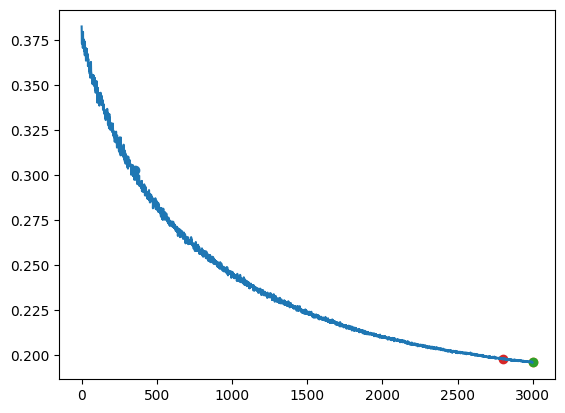

In [4]:
idx_curve =-2
idx_start = 500
idx_end = -1
loss_vec = avg_results_PEPG[idx_curve]['test_loss'][idx_start:idx_end]
e_conv1 = convergence_relative_improvement(loss_vec, threshold=5e-3, window=50)
e_conv2 = convergence_slope_loglog(loss_vec, threshold=1e-2, window=50)
e_conv3 = convergence_relative_slope_loglog(loss_vec, fraction=1-2, window=50)
e_conv4 = knee_point_loglog(loss_vec)

plt.plot(loss_vec)
plt.scatter(e_conv1,loss_vec[e_conv1])
plt.scatter(e_conv2,loss_vec[e_conv2])
plt.scatter(e_conv3,loss_vec[e_conv3])
plt.scatter(e_conv4,loss_vec[e_conv4])


### Knee method below works quite well and is consistent
- it measures the distance from the normalized loss curve to a diagonal knee is reached when distance is max

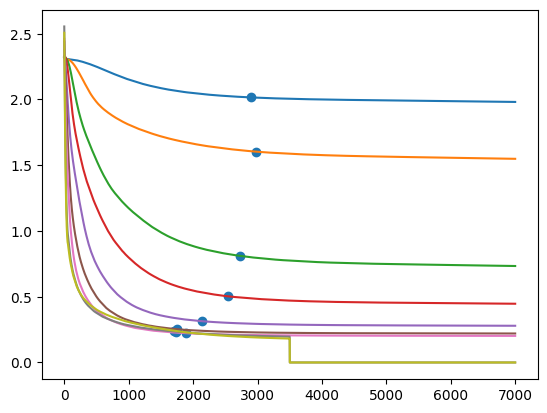

In [5]:

N_neurons_vec = [5, 10, 20 ,30, 50, 75, 100,150,180]


test_loss_mat = np.zeros((len(N_neurons_vec),len(avg_results_PEPG[0]['test_loss'])))
train_loss_mat = np.zeros((len(N_neurons_vec),len(avg_results_PEPG[0]['train_loss'])))
test_loss_smooth_mat = np.zeros((len(N_neurons_vec),len(avg_results_PEPG[0]['test_loss'])))
test_acc_mat = np.zeros((len(N_neurons_vec),len(avg_results_PEPG[0]['test_acc'])))

idx_start = 500
knee_idx_PEPG = []

for k,D in enumerate(avg_results_PEPG):

    test_loss_mat[k,:len( D['test_loss'])] = D['test_loss']
    train_loss_mat[k,:len(D['train_loss'])] = D['train_loss']
    
    test_loss_smooth = scipy.signal.savgol_filter(test_loss_mat[k,:len( D['test_loss'])],window_length=100,polyorder=3,axis=-1)
    test_loss_smooth_mat[k,:len(test_loss_smooth)] = test_loss_smooth
    test_acc_mat[k,:len(D['test_acc'])] = D['test_acc']

    kneedle = KneeLocator(
        np.arange(idx_start,np.shape(test_loss_smooth)[-1]), test_loss_smooth[idx_start:],
        S=1.0,                     # sensitivity (larger -> fewer knees)
        curve="convex",            # try "concave" if your curve bends the other way
        direction="decreasing",    # loss goes down with epochs
        online=False
    )

    knee_idx_PEPG.append(int(kneedle.knee + idx_start)) 

knee_idx_PEPG = np.array(knee_idx_PEPG)
loss_PEPG_conv = test_loss_smooth_mat[np.arange(len(N_neurons_vec)),knee_idx_PEPG]
acc_PEPG_conv = test_acc_mat[np.arange(len(N_neurons_vec)),knee_idx_PEPG]

plt.plot(test_loss_smooth_mat.T)
plt.scatter(knee_idx_PEPG,loss_PEPG_conv)

In [6]:
acc_PEPG_conv

array([25.15      , 39.14      , 81.16333333, 89.87333333, 93.64666667,
       95.51333333, 96.65      , 97.62      , 97.80666667])

In [7]:
print(knee_idx_PEPG)

[2898 2970 2720 2540 2141 1745 1891 1729 1708]


[4045, 8180, 16750, 25720, 44860, 71035, 99710, 164560, 208270]
slope 1.512827013928204
intercept -4.1172757214113895


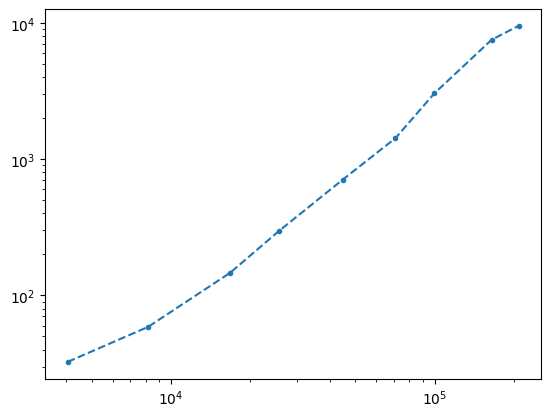

In [12]:
N_dim_vec_PEPG = []
for k in range(len(avg_results_PEPG)):
    N_dim = int(avg_results_PEPG[k]['n_params'])
    N_dim_vec_PEPG.append(N_dim)
#N_dim_vec = [4045, 8180, 16750, 25720, 44860, 71035, 99710, 164560]


print(N_dim_vec_PEPG)
# peak memory data below was measured with the following dcript in the terminal command with or without scalene  : "scalene --html memory_profile_PEPG.py" only need to change N_dim in the .py script repeatedly
#added tracemalloc memory profiling because scalene does not monitor such a low memory usage per epoch

#PEPG_mem_perepoch = np.array([4.09,14.35,57.25,133.9,404.4,1012.13,1994.5,5422])/2/1000 #RSS delta cost in GB more accurate, divide by 2 bcause float32 not 64

#PEPG_mem_perepoch = np.array([10.173,15.295 ,36.797 , 76.5, 209.9,513.4, 1005.5,2720.037])/1000 #with peak mem CUDA torch profiler
PEPG_mem_perepoch = np.array([11.2,19.76,53.82,117.27,330.8,816.62,1603.96,4347.31,5566.28])/1000 #with peak mem CUDA torch profiler


PEPG_cost_to_conv = PEPG_mem_perepoch * knee_idx_PEPG
plt.loglog(N_dim_vec_PEPG,PEPG_cost_to_conv,'--.')

a_PEPG, b_PEPG = np.polyfit(np.log10(N_dim_vec_PEPG), np.log10(PEPG_cost_to_conv), 1)  # linear fit
print(f'slope {a_PEPG}')
print(f'intercept {b_PEPG}')

In [13]:
N_neurons_vec = [5, 10, 20 ,30, 50, 75, 100,150,250]

with gzip.open('paramscan_PNN_SPSA_MNIST_run1.pkl.gz', 'rb') as f:
    results_SPSA1 = pickle.load(f)

with gzip.open('paramscan_PNN_SPSA_MNIST_run2.pkl.gz', 'rb') as f:
    results_SPSA2 = pickle.load(f)

with gzip.open('paramscan_PNN_SPSA_MNIST_run3.pkl.gz', 'rb') as f:
    results_SPSA3 = pickle.load(f)

dicts_list = [results_SPSA1, results_SPSA2,results_SPSA3]  # list of runs

# Average them
avg_results_SPSA = []
for i in range(len(N_neurons_vec)):          # loop over neuron settings
    avg_dict = {}
    keys = dicts_list[0][i].keys()           # e.g. 'train_loss', 'test_loss'
    for key in keys:
        stacked = np.stack([d[i][key] for d in dicts_list])  # shape: (n_runs, vec_len)
        avg_dict[key] = stacked.mean(axis=0)
    avg_results_SPSA.append(avg_dict)

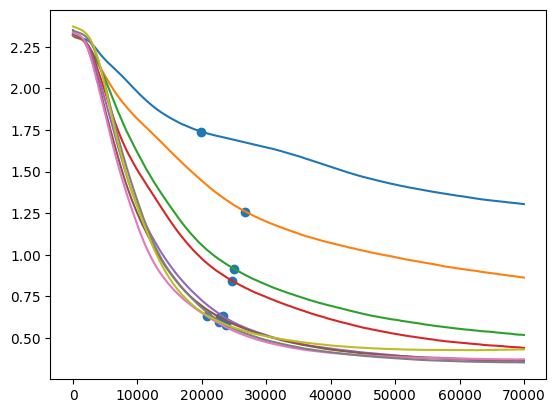

In [14]:

N_neurons_vec = [5, 10, 20 ,30, 50, 75, 100,150,250]


test_loss_mat = np.zeros((len(N_neurons_vec),len(avg_results_SPSA[0]['test_loss'])))
train_loss_mat = np.zeros((len(N_neurons_vec),len(avg_results_SPSA[0]['train_loss'])))
test_acc_mat = np.zeros((len(N_neurons_vec),len(avg_results_SPSA[0]['test_acc'])))

for k,D in enumerate(avg_results_SPSA):

    test_loss_mat[k,:] = D['test_loss']
    train_loss_mat[k,:] = D['train_loss']
    test_acc_mat[k,:len(D['test_acc'])] = D['test_acc']


idx_start = 3000
test_loss_smooth = scipy.signal.savgol_filter(test_loss_mat,window_length=100,polyorder=3,axis=-1)
knee_idx_SPSA = []
for k in range(len(N_neurons_vec)):
    kneedle = KneeLocator(
        np.arange(idx_start,np.shape(test_loss_smooth)[-1]), test_loss_smooth[k,idx_start:len(avg_results_SPSA[0]['test_loss'])+1],
        S=1.0,                     # sensitivity (larger -> fewer knees)
        curve="convex",            # try "concave" if your curve bends the other way
        direction="decreasing",    # loss goes down with epochs
        online=False
    )

    knee_idx_SPSA.append(int(kneedle.knee + idx_start)) 

knee_idx_SPSA = np.array(knee_idx_SPSA)
loss_SPSA_conv = test_loss_smooth[np.arange(len(N_neurons_vec)),knee_idx_SPSA]
acc_SPSA_conv = test_acc_mat[np.arange(len(N_neurons_vec)),knee_idx_SPSA]

plt.plot(test_loss_smooth.T)
plt.scatter(knee_idx_SPSA,loss_SPSA_conv)

In [18]:
knee_idx_SPSA

array([19894, 26764, 24994, 24742, 23261, 22750, 20738, 23726, 22657])

[4045, 8180, 16750, 25720, 44860, 71035, 99710, 164560, 324260]
slope 0.9935544389693869
intercept 0.9935544389693869


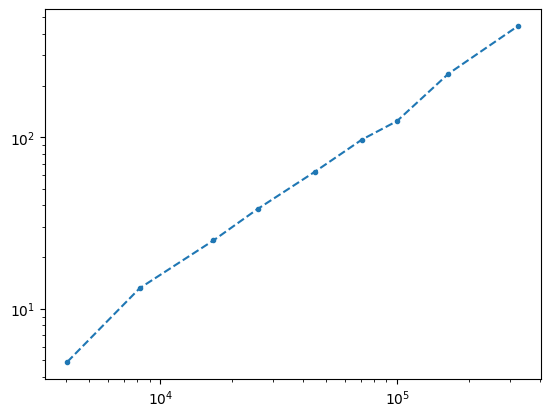

In [17]:
N_dim_vec_SPSA = []
for k in range(len(avg_results_SPSA)):
    N_dim = int(avg_results_SPSA[k]['n_params'])
    N_dim_vec_SPSA.append(N_dim)
#N_dim_vec_SPSA = [4045, 8180, 16750, 25720, 44860, 71035, 99710, 164560, 324260]


print(N_dim_vec_SPSA)
# peak memory data below was measured with the following terminal command  : "scalene --html memory_profile_SPSA.py" only need to change N_dim in the .py script repeatedly
#added tracemalloc memory profiling because scalene does not monitor such a low memory usage per epoch

#SPSA_mem_perepoch = np.array([0.545, 0.885,1.75,2.3,3.9,5.96,8.1,12.9,25.1])/2/1000 # RSS DELTA cost in MB more accurate

#SPSA_mem_perepoch = np.array([0.082, 0.164,0.335,0.515,0.889,1.421,1.994,3.292,6.487])/1000 # CUDA Delta

SPSA_mem_perepoch = np.array([0.246, 0.492, 1, 1.54,2.7,4.26,5.98,9.88,19.67])/1000 # CUDA Peak


SPSA_cost_to_conv = SPSA_mem_perepoch * knee_idx_SPSA
plt.loglog(N_dim_vec_SPSA,SPSA_cost_to_conv,'--.')

a_SPSA, b_SPSA = np.polyfit(np.log10(N_dim_vec_SPSA), np.log10(SPSA_cost_to_conv), 1)  # linear fit
print(f'slope {a_SPSA}')
print(f'intercept {a_SPSA}')

In [24]:
knee_idx_SPSA

array([19894, 26764, 24994, 24742, 23261, 22750, 20738, 23726, 22657])

In [21]:
N_neurons_vec = [5, 10, 20 ,30, 50, 75, 100,150,250,300,400]

with gzip.open('paramscan_PNN_BP_MNIST_run1.pkl.gz', 'rb') as f:
    results_BP1 = pickle.load(f)

with gzip.open('paramscan_PNN_BP_MNIST_run2.pkl.gz', 'rb') as f:
    results_BP2 = pickle.load(f)

with gzip.open('paramscan_PNN_BP_MNIST_run3.pkl.gz', 'rb') as f:
    results_BP3 = pickle.load(f)

dicts_list = [results_BP1, results_BP2,results_BP3]  # list of runs

# Average them
avg_results_BP = []
for i in range(len(N_neurons_vec)):          # loop over neuron settings
    avg_dict = {}
    keys = dicts_list[0][i].keys()           # e.g. 'train_loss', 'test_loss'
    for key in keys:
        stacked = np.stack([d[i][key] for d in dicts_list])  # shape: (n_runs, vec_len)
        avg_dict[key] = stacked.mean(axis=0)
    avg_results_BP.append(avg_dict)

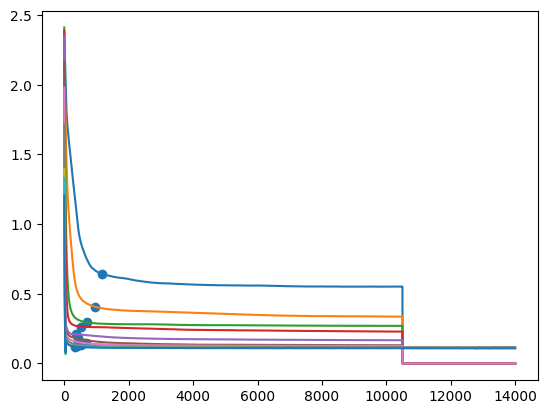

In [27]:

N_neurons_vec = [5, 10, 20 ,30, 50, 75, 100,150,250,300,400]


test_loss_mat = np.zeros((len(N_neurons_vec),len(avg_results_BP[-1]['test_loss'])))
train_loss_mat = np.zeros((len(N_neurons_vec),len(avg_results_BP[-1]['train_loss'])))
test_loss_smooth_mat = np.zeros((len(N_neurons_vec),len(avg_results_BP[-1]['test_loss'])))
test_acc_mat = np.zeros((len(N_neurons_vec),len(avg_results_BP[-1]['test_acc'])))
idx_start = 100
knee_idx_BP = []

for k,D in enumerate(avg_results_BP):

    test_loss_mat[k,:len( D['test_loss'])] = D['test_loss']
    train_loss_mat[k,:len(D['train_loss'])] = D['train_loss']
    test_acc_mat[k,:len(D['test_acc'])] = D['test_acc']
    
    test_loss_smooth = scipy.signal.savgol_filter(test_loss_mat[k,:len( D['test_loss'])],window_length=100,polyorder=3,axis=-1)
    test_loss_smooth_mat[k,:len(test_loss_smooth)] = test_loss_smooth

    kneedle = KneeLocator(
        np.arange(idx_start,np.shape(test_loss_smooth)[-1]), test_loss_smooth[idx_start:],
        S=1.0,                     # sensitivity (larger -> fewer knees)
        curve="convex",            # try "concave" if your curve bends the other way
        direction="decreasing",    # loss goes down with epochs
        online=False
    )

    knee_idx_BP.append(int(kneedle.knee + idx_start)) 

knee_idx_BP = np.array(knee_idx_BP)
loss_BP_conv = test_loss_smooth_mat[np.arange(len(N_neurons_vec)),knee_idx_BP]
acc_BP_conv = test_acc_mat[np.arange(len(N_neurons_vec)),knee_idx_BP]
plt.plot(test_loss_smooth_mat.T)
plt.scatter(knee_idx_BP,loss_BP_conv)

In [23]:
knee_idx_BP

array([1161,  953,  715,  516,  372,  413,  660,  513,  389,  374,  338])

In [28]:
acc_BP_conv

array([84.98666667, 91.44666667, 94.34      , 94.88      , 96.10666667,
       96.94333333, 97.69      , 97.82333333, 98.06      , 98.03      ,
       98.11      ])

[4045, 8180, 16750, 25720, 44860, 71035, 99710, 164560, 324260, 419110, 638810]
slope 0.1129493351891418
intercept 0.25965744959146136


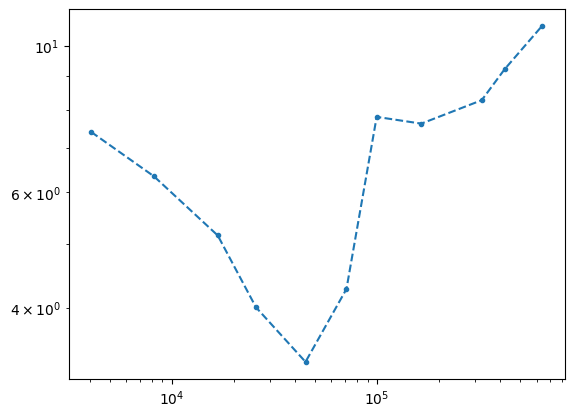

In [ ]:
N_dim_vec_BP = []
for k in range(len(avg_results_BP)):
    N_dim = int(avg_results_BP[k]['n_params'])
    N_dim_vec_BP.append(N_dim)
#N_dim_vec_BP = [4045, 8180, 16750, 25720, 44860, 71035, 99710, 164560, 324260]

print(N_dim_vec_BP)
# peak memory data below was measured with the following terminal command  : "scalene --html memory_profile_SPSA.py" only need to change N_dim in the .py script repeatedly
#added tracemalloc memory profiling because scalene does not monitor such a low memory usage per epoch
#BP_mem_perepoch = np.array([0.016,0.033,0.067, 0.1, 0.179, 0.284, 0.399,0.658 ,1.297])/2/1000

#BP_mem_perepoch = np.array([0.125,0.251,0.5,0.772,1.32,2.04,2.795,4.43,8.2])/1000 # cost in MB more accurate

#BP_mem_perepoch = np.array([22.42,22.58,22.98,23.42,24.32,25.51,26.76,29.44,35.53])/1000 #peak total
#BP_mem_perepoch = np.array([6.3,6.647,7.203,7.764,8.898,10.342,11.815,14.846,21.251])/2/1000 #peak total torch memory profile
#BP_mem_perepoch = np.array([0.053, 0.1, 0.199, 0.302, 0.522, 0.822, 1.152, 1.896, 3.728])/2/1000 #peak total theory batch = 1

#BP_mem_perepoch = np.array([0.053, 0.131, 0.180, 0.32, 0.522, 0.786, 0.92, 1.57, 2.9])/2/1000 #peak total numpy class

BP_mem_perepoch = np.array([6.371, 6.647, 7.203, 7.764, 8.898, 10.342, 11.815, 14.846, 21.251, 24.625, 31.717])/1000 #peak total theory batch = 1000 torch cuda

#BP_mem_perepoch = np.array([22.4,22.7,23.34,23.98,25.28,26.96,28.72,32.4,40.48,45.45,54.28])/1000 #peak  batch = 1000 torch cuda

BP_cost_to_conv = BP_mem_perepoch * knee_idx_BP
plt.loglog(N_dim_vec_BP,BP_cost_to_conv,'--.')

a_BP, b_BP = np.polyfit(np.log10(N_dim_vec_BP), np.log10(BP_cost_to_conv), 1)  # linear fit
print(f'slope {a_BP}')
print(f'intercept {b_BP}')

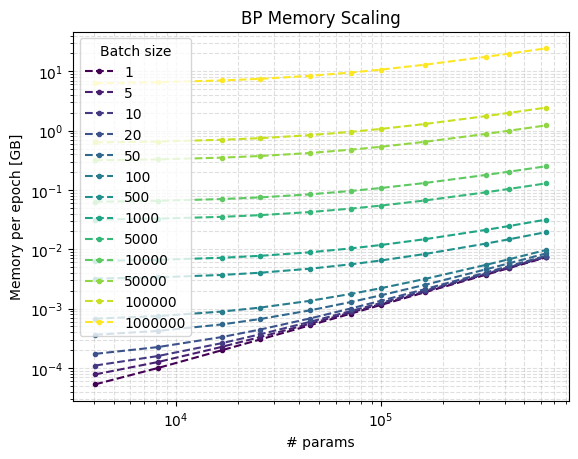

In [75]:
BP_mem_perepoch_1 = np.array([0.053, 0.1, 0.199, 0.302, 0.522, 0.822, 1.152, 1.896, 3.728, 4.816, 7.335])/1000 #peak total theory batch = 1
BP_mem_perepoch_5 = np.array([0.078, 0.126, 0.227, 0.332, 0.555, 0.861, 1.194, 1.948, 3.799, 4.895, 7.433])/1000 #peak total theory batch = 1
BP_mem_perepoch_10 = np.array([0.11, 0.159, 0.262, 0.369, 0.597, 0.908, 1.248, 2.013, 3.886, 4.995, 7.555])/1000 #peak total theory batch = 1
BP_mem_perepoch_20 = np.array([0.173, 0.225, 0.332, 0.444, 0.681, 1.004, 1.355, 2.142, 4.062, 5.193, 7.799])/1000 #peak total theory batch = 1
BP_mem_perepoch_50 = np.array([0.363, 0.421, 0.542, 0.668, 0.933, 1.289, 1.675, 2.531, 4.588, 5.788, 8.531])/1000 #peak total theory batch = 1
BP_mem_perepoch_100 = np.array([0.679, 0.749, 0.893, 1.041, 1.352, 1.766, 2.208, 3.179, 5.465, 6.779, 9.751])/1000 #peak total theory batch = 1
BP_mem_perepoch_500 = np.array([3.209, 3.37, 3.697, 4.029, 4.706, 5.577, 6.478, 8.364, 12.481, 14.711, 19.514])/1000 #peak total theory batch = 1
BP_mem_perepoch_1000 = np.array([6.371, 6.647, 7.203, 7.764, 8.898, 10.342, 11.815, 14.846, 21.251, 24.625, 31.717])/1000 #peak total theory batch = 1
BP_mem_perepoch_5000 = np.array([31.67, 32.862, 35.249, 37.64, 42.437, 48.458, 54.509, 66.695, 91.411, 103.94, 129.343])/1000 #peak total theory batch = 1
BP_mem_perepoch_10000 = np.array([63.294, 65.63, 70.306, 74.986, 84.36, 96.104, 107.876, 131.507, 179.111, 203.084, 251.375])/1000 #peak total theory batch = 1
BP_mem_perepoch_50000 = np.array([316.285, 327.776, 350.762, 373.753, 419.749, 477.269, 534.817, 650.0, 880.71, 996.236, 1227.632])/1000
BP_mem_perepoch_100000 = np.array([632.523, 655.459, 701.333, 747.212, 838.984, 953.724, 1068.493, 1298.117, 1757.709, 1987.676, 2447.954])/1000
BP_mem_perepoch_1000000 = np.array([6324.814, 6553.744, 7011.605, 7469.472, 8385.218, 9529.927, 10674.664, 12964.225, 17543.689, 19833.593, 24413.744])/1000


# Your y-data arrays in a list (in the same order as you plot them)
BP_arrays = [
    BP_mem_perepoch_1,
    BP_mem_perepoch_5,
    BP_mem_perepoch_10,
    BP_mem_perepoch_20,
    BP_mem_perepoch_50,
    BP_mem_perepoch_100,
    BP_mem_perepoch_500,
    BP_mem_perepoch_1000,
    BP_mem_perepoch_5000,
    BP_mem_perepoch_10000,
    BP_mem_perepoch_50000,
    BP_mem_perepoch_100000,
    BP_mem_perepoch_1000000
]

# The labels for the legend
labels = ["1", "5", "10", "20", "50", "100", "500", "1000","5000","10000","50000","100000","1000000"]

# Build a colormap proportional to number of curves
cmap = plt.cm.viridis
colors = cmap(np.linspace(0, 1, len(BP_arrays)))

a_BP_batchsweep = []
b_BP_batchsweep = []
plt.figure()
for arr, label, color in zip(BP_arrays, labels, colors):
    plt.loglog(N_dim_vec_BP, arr, '--.', color=color, label=label)
    a_BP, b_BP = np.polyfit(np.log10(N_dim_vec_BP[-5:]), np.log10(arr[-5:]), 1)  # linear fit
    a_BP_batchsweep.append(a_BP)
    b_BP_batchsweep.append(b_BP)
    

# Legend depending on number
plt.legend(title="Batch size", fontsize=10)

plt.xlabel("# params")
plt.ylabel("Memory per epoch [GB]")
plt.title("BP Memory Scaling")
plt.grid(True, which="both", ls="--", alpha=0.4)

plt.show()




In [76]:
a_BP_batchsweep

[np.float64(0.9967051199117775),
 np.float64(0.9845256963622673),
 np.float64(0.9695401741807897),
 np.float64(0.9424585391611869),
 np.float64(0.8764787463341417),
 np.float64(0.7994011469811713),
 np.float64(0.5929210995595047),
 np.float64(0.5310272437534378),
 np.float64(0.4650848237813052),
 np.float64(0.455420191189301),
 np.float64(0.44741165236333297),
 np.float64(0.4463928895680493),
 np.float64(0.44547225311795524)]

Text(0, 0.5, 'Asymptote slope')

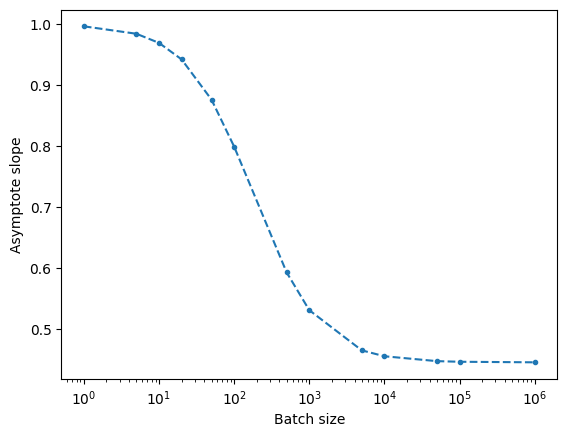

In [77]:
labels = [int(i) for i in labels]
plt.semilogx(labels,a_BP_batchsweep,'.--')
plt.xlabel("Batch size")
plt.ylabel("Asymptote slope")

In [29]:
N_neurons_vec = [5, 10, 20 ,30, 50, 75, 100,150]

with gzip.open('paramscan_PNN_PEPG_MNIST_run1.pkl.gz', 'rb') as f:
    results_CMA1 = pickle.load(f)

with gzip.open('paramscan_PNN_PEPG_MNIST_run2.pkl.gz', 'rb') as f:
    results_CMA2 = pickle.load(f)

with gzip.open('paramscan_PNN_PEPG_MNIST_run3.pkl.gz', 'rb') as f:
    results_CMA3 = pickle.load(f)

dicts_list = [results_CMA1, results_CMA2,results_CMA3]  # list of runs

# Average them
avg_results_CMA = []
for i in range(len(N_neurons_vec)):          # loop over neuron settings
    avg_dict = {}
    keys = dicts_list[0][i].keys()           # e.g. 'train_loss', 'test_loss'
    for key in keys:
        stacked = np.stack([d[i][key] for d in dicts_list])  # shape: (n_runs, vec_len)
        avg_dict[key] = stacked.mean(axis=0)
    avg_results_CMA.append(avg_dict)

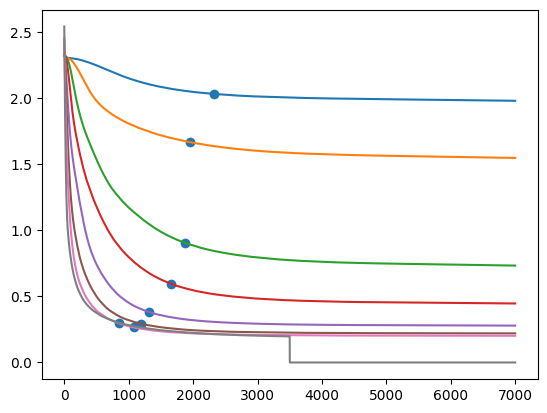

In [32]:

N_neurons_vec = [5, 10, 20 ,30, 50, 75, 100,150]


test_loss_mat = np.zeros((len(N_neurons_vec),len(avg_results_CMA[0]['test_loss'])))
train_loss_mat = np.zeros((len(N_neurons_vec),len(avg_results_CMA[0]['train_loss'])))
test_loss_smooth_mat = np.zeros((len(N_neurons_vec),len(avg_results_CMA[0]['test_loss'])))
test_acc_mat = np.zeros((len(N_neurons_vec),len(avg_results_CMA[0]['test_acc'])))
idx_start = 100
knee_idx_CMA = []

for k,D in enumerate(avg_results_CMA):

    test_loss_mat[k,:len( D['test_loss'])] = D['test_loss']
    train_loss_mat[k,:len(D['train_loss'])] = D['train_loss']
    test_acc_mat[k,:len(D['test_acc'])] = D['test_acc']
    
    test_loss_smooth = scipy.signal.savgol_filter(test_loss_mat[k,:len( D['test_loss'])],window_length=100,polyorder=3,axis=-1)
    test_loss_smooth_mat[k,:len(test_loss_smooth)] = test_loss_smooth

    kneedle = KneeLocator(
        np.arange(idx_start,np.shape(test_loss_smooth)[-1]), test_loss_smooth[idx_start:],
        S=1.0,                     # sensitivity (larger -> fewer knees)
        curve="convex",            # try "concave" if your curve bends the other way
        direction="decreasing",    # loss goes down with epochs
        online=False
    )

    knee_idx_CMA.append(int(kneedle.knee + idx_start)) 

knee_idx_CMA = np.array(knee_idx_CMA)
loss_CMA_conv = test_loss_smooth_mat[np.arange(len(N_neurons_vec)),knee_idx_CMA]
acc_CMA_conv = test_acc_mat[np.arange(len(N_neurons_vec)),knee_idx_CMA]
plt.plot(test_loss_smooth_mat.T)
plt.scatter(knee_idx_CMA,loss_CMA_conv)

[4045, 8180, 16750, 25720, 44860, 71035, 99710, 164560]
slope 1.7414945003100804
intercept -5.480450202997375


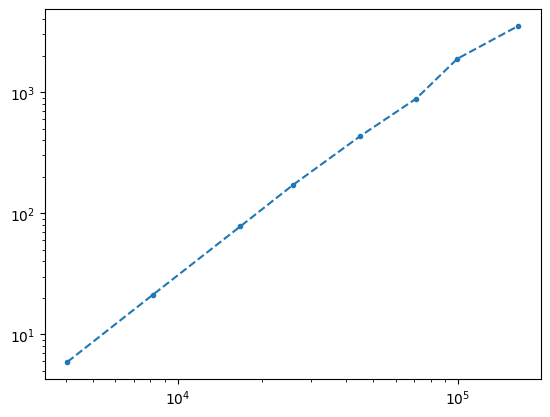

In [ ]:
N_dim_vec_CMA = []
for k in range(len(avg_results_PEPG)):
    N_dim = int(avg_results_PEPG[k]['n_params'])
    N_dim_vec_CMA.append(N_dim)
#N_dim_vec = [4045, 8180, 16750, 25720, 44860, 71035, 99710, 164560]


print(N_dim_vec_CMA)
# peak memory data below was measured with the following dcript in the terminal command with or without scalene  : "scalene --html memory_profile_PEPG.py" only need to change N_dim in the .py script repeatedly
#added tracemalloc memory profiling because scalene does not monitor such a low memory usage per epoch

CMA_mem_perepoch = np.array([4.09,14.35,57.25,133.9,404.4,1012.13,1994.5,5422])/2/1000 #RSS delta cost in GB more accurate, divide by 2 bcause float32 not 64
CMA_mem_perepoch = np.array([3.953,15.974,,])/2/1000 #RSS delta cost in GB more accurate, divide by 2 bcause float32 not 64

CMA_cost_to_conv = CMA_mem_perepoch * knee_idx_PEPG
plt.loglog(N_dim_vec_CMA,CMA_cost_to_conv,'--.')

a_PEPG, b_PEPG = np.polyfit(np.log10(N_dim_vec_CMA), np.log10(CMA_cost_to_conv), 1)  # linear fit
print(f'slope {a_PEPG}')
print(f'intercept {b_PEPG}')

### Performance vs number params

BP loss-fit:    slope=-0.379, intercept=1.106
PEPG loss-fit:  slope=-0.661, intercept=2.687
SPSA loss-fit:  slope=-0.411, intercept=1.715


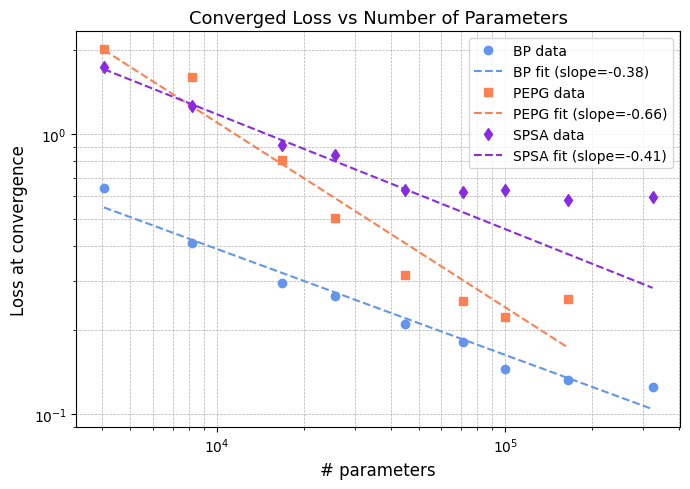

In [34]:
# ----- power-law fits (log-log) -----
a_BP_l,   b_BP_l   = np.polyfit(np.log10(N_dim_vec_BP), np.log10(loss_BP_conv),   1)
a_PEPG_l, b_PEPG_l = np.polyfit(np.log10(N_dim_vec_PEPG), np.log10(loss_PEPG_conv), 1)
a_SPSA_l, b_SPSA_l = np.polyfit(np.log10(N_dim_vec_SPSA[:-4]), np.log10(loss_SPSA_conv[:-4]), 1)

print(f"BP loss-fit:    slope={a_BP_l:.3f}, intercept={b_BP_l:.3f}")
print(f"PEPG loss-fit:  slope={a_PEPG_l:.3f}, intercept={b_PEPG_l:.3f}")
print(f"SPSA loss-fit:  slope={a_SPSA_l:.3f}, intercept={b_SPSA_l:.3f}")

# Predicted fits in original scale
fit_BP    = 10**(a_BP_l   * np.log10(N_dim_vec_BP) + b_BP_l)
fit_PEPG  = 10**(a_PEPG_l * np.log10(N_dim_vec_PEPG) + b_PEPG_l)
fit_SPSA  = 10**(a_SPSA_l * np.log10(N_dim_vec_SPSA) + b_SPSA_l)

# ----- plotting -----
plt.figure(figsize=(7,5))

# BP — cornflower blue
plt.loglog(N_dim_vec_BP, loss_BP_conv, 'o', color='cornflowerblue', label='BP data')
plt.loglog(N_dim_vec_BP, fit_BP, '--',  color='cornflowerblue', label=f'BP fit (slope={a_BP_l:.2f})')

# PEPG — coral
plt.loglog(N_dim_vec_PEPG, loss_PEPG_conv, 's', color='coral', label='PEPG data')
plt.loglog(N_dim_vec_PEPG, fit_PEPG, '--',  color='coral', label=f'PEPG fit (slope={a_PEPG_l:.2f})')

# SPSA — blueviolet
plt.loglog(N_dim_vec_SPSA, loss_SPSA_conv, 'd', color='blueviolet', label='SPSA data')
plt.loglog(N_dim_vec_SPSA, fit_SPSA, '--',  color='blueviolet', label=f'SPSA fit (slope={a_SPSA_l:.2f})')

plt.xlabel(r'# parameters', fontsize=12)
plt.ylabel('Loss at convergence', fontsize=12)
plt.title('Converged Loss vs Number of Parameters', fontsize=13)
plt.legend()
plt.grid(True, which="both", ls="--", lw=0.5)
plt.tight_layout()
plt.show()

BP loss-fit:    slope=0.029, intercept=1.844
PEPG loss-fit:  slope=0.825, intercept=-1.596
SPSA loss-fit:  slope=0.455, intercept=-0.059


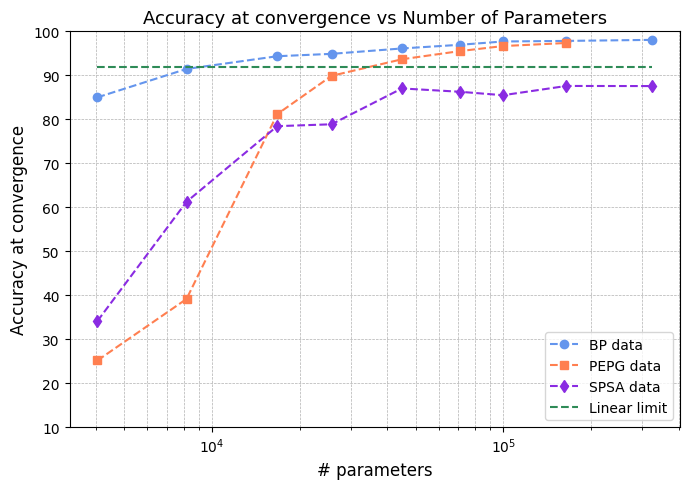

In [35]:
# ----- power-law fits (log-log) -----
a_BP_l,   b_BP_l   = np.polyfit(np.log10(N_dim_vec_BP), np.log10(acc_BP_conv),   1)
a_PEPG_l, b_PEPG_l = np.polyfit(np.log10(N_dim_vec_PEPG[:-5]), np.log10(acc_PEPG_conv[:-5]), 1)
a_SPSA_l, b_SPSA_l = np.polyfit(np.log10(N_dim_vec_SPSA[:-5]), np.log10(acc_SPSA_conv[:-5]), 1)

print(f"BP loss-fit:    slope={a_BP_l:.3f}, intercept={b_BP_l:.3f}")
print(f"PEPG loss-fit:  slope={a_PEPG_l:.3f}, intercept={b_PEPG_l:.3f}")
print(f"SPSA loss-fit:  slope={a_SPSA_l:.3f}, intercept={b_SPSA_l:.3f}")

# Predicted fits in original scale
fit_BP    = 10**(a_BP_l   * np.log10(N_dim_vec_BP) + b_BP_l)
fit_PEPG  = 10**(a_PEPG_l * np.log10(N_dim_vec_PEPG) + b_PEPG_l)
fit_SPSA  = 10**(a_SPSA_l * np.log10(N_dim_vec_SPSA) + b_SPSA_l)

# ----- plotting -----
plt.figure(figsize=(7,5))

# BP — cornflower blue
plt.semilogx(N_dim_vec_BP, acc_BP_conv, '--o', color='cornflowerblue', label='BP data')
#plt.loglog(N_dim_vec_BP, fit_BP, '--',  color='cornflowerblue', label=f'BP fit (slope={a_BP_l:.2f})')

# PEPG — coral
plt.semilogx(N_dim_vec_PEPG, acc_PEPG_conv, '--s', color='coral', label='PEPG data')
#plt.loglog(N_dim_vec_PEPG, fit_PEPG, '--',  color='coral', label=f'PEPG fit (slope={a_PEPG_l:.2f})')

# SPSA — blueviolet
plt.semilogx(N_dim_vec_SPSA, acc_SPSA_conv, '--d', color='blueviolet', label='SPSA data')
#plt.loglog(N_dim_vec_SPSA, fit_SPSA, '--',  color='blueviolet', label=f'SPSA fit (slope={a_SPSA_l:.2f})')

#linear classifier
# linear limit
plt.semilogx(N_dim_vec_BP, np.ones(len(N_dim_vec_BP))*92, '--', color='seagreen', label='Linear limit')

plt.xlabel(r'# parameters', fontsize=12)
plt.ylabel('Accuracy at convergence', fontsize=12)
plt.title('Accuracy at convergence vs Number of Parameters', fontsize=13)
plt.ylim([10,100])
plt.legend()
plt.grid(True, which="both", ls="--", lw=0.5)
plt.tight_layout()
plt.show()

### Cost to convergence plot

BP:    slope=0.585, intercept=-2.959
PEPG:  slope=1.355, intercept=-3.597
SPSA:  slope=0.992, intercept=-3.295


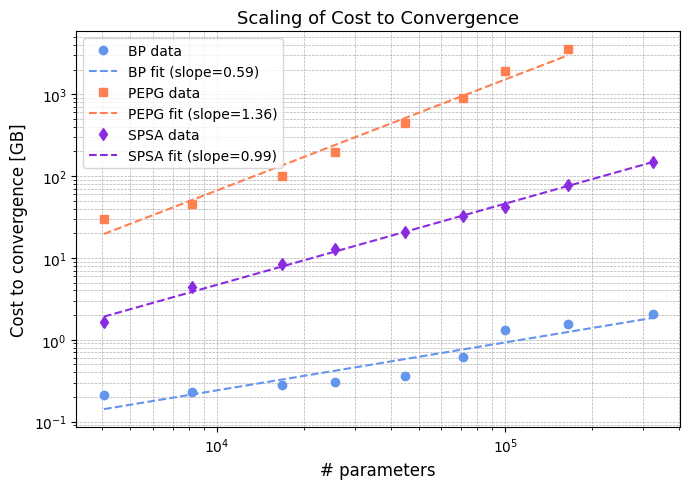

In [36]:
# Fit lines (log-log)
a_BP, b_BP = np.polyfit(np.log10(N_dim_vec_BP), np.log10(BP_cost_to_conv), 1)
a_PEPG, b_PEPG = np.polyfit(np.log10(N_dim_vec_PEPG), np.log10(PEPG_cost_to_conv), 1)
a_SPSA, b_SPSA = np.polyfit(np.log10(N_dim_vec_SPSA), np.log10(SPSA_cost_to_conv), 1)

# Print slopes and intercepts
print(f"BP:    slope={a_BP:.3f}, intercept={b_BP:.3f}")
print(f"PEPG:  slope={a_PEPG:.3f}, intercept={b_PEPG:.3f}")
print(f"SPSA:  slope={a_SPSA:.3f}, intercept={b_SPSA:.3f}")

# Plot data and fits
plt.figure(figsize=(7,5))

# BP - black
plt.loglog(N_dim_vec_BP, BP_cost_to_conv, 'o', color='cornflowerblue', label='BP data')
plt.loglog(N_dim_vec_BP, 10**(a_BP*np.log10(N_dim_vec_BP) + b_BP), '--', color='cornflowerblue', label=f'BP fit (slope={a_BP:.2f})')

# PEPG - orange
plt.loglog(N_dim_vec_PEPG, PEPG_cost_to_conv, 's', color='coral', label='PEPG data')
plt.loglog(N_dim_vec_PEPG, 10**(a_PEPG*np.log10(N_dim_vec_PEPG) + b_PEPG), '--', color='coral', label=f'PEPG fit (slope={a_PEPG:.2f})')

# SPSA - purple
plt.loglog(N_dim_vec_SPSA, SPSA_cost_to_conv, 'd', color='blueviolet', label='SPSA data')
plt.loglog(N_dim_vec_SPSA, 10**(a_SPSA*np.log10(N_dim_vec_SPSA) + b_SPSA), '--', color='blueviolet', label=f'SPSA fit (slope={a_SPSA:.2f})')


# Labels and style
plt.xlabel(r'# parameters', fontsize=12)
plt.ylabel('Cost to convergence [GB]', fontsize=12)
plt.title('Scaling of Cost to Convergence', fontsize=13)
plt.legend()
plt.grid(True, which="both", ls="--", lw=0.5)
plt.tight_layout()
plt.show()

### Loss vs cost to convergence

BP:    slope=-0.559, intercept=-0.787
PEPG:  slope=-0.638, intercept=1.222
SPSA:  slope=-0.393, intercept=0.335


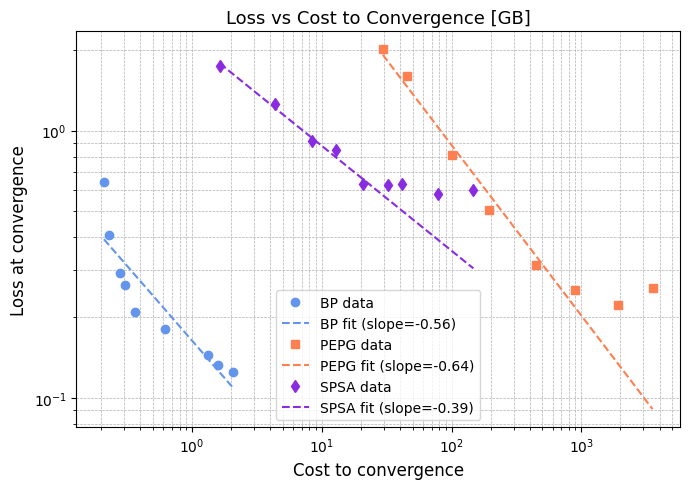

In [37]:
# Fit lines (log-log)
a_BP, b_BP = np.polyfit(np.log10(BP_cost_to_conv),   np.log10(loss_BP_conv),   1)
a_PEPG, b_PEPG = np.polyfit(np.log10(PEPG_cost_to_conv[:-2]), np.log10(loss_PEPG_conv[:-2]), 1)
a_SPSA, b_SPSA = np.polyfit(np.log10(SPSA_cost_to_conv[:-4]), np.log10(loss_SPSA_conv[:-4]), 1)

# Print slopes and intercepts
print(f"BP:    slope={a_BP:.3f}, intercept={b_BP:.3f}")
print(f"PEPG:  slope={a_PEPG:.3f}, intercept={b_PEPG:.3f}")
print(f"SPSA:  slope={a_SPSA:.3f}, intercept={b_SPSA:.3f}")

# Plot data and fits
plt.figure(figsize=(7,5))

# BP — cornflower blue
plt.loglog(BP_cost_to_conv, loss_BP_conv, 'o', color='cornflowerblue', label='BP data')
plt.loglog(BP_cost_to_conv, 10**(a_BP*np.log10(BP_cost_to_conv) + b_BP), '--', color='cornflowerblue', label=f'BP fit (slope={a_BP:.2f})')

# PEPG — coral
plt.loglog(PEPG_cost_to_conv, loss_PEPG_conv, 's', color='coral', label='PEPG data')
plt.loglog(PEPG_cost_to_conv, 10**(a_PEPG*np.log10(PEPG_cost_to_conv) + b_PEPG), '--', color='coral', label=f'PEPG fit (slope={a_PEPG:.2f})')

# SPSA — blueviolet
plt.loglog(SPSA_cost_to_conv, loss_SPSA_conv, 'd', color='blueviolet', label='SPSA data')
plt.loglog(SPSA_cost_to_conv, 10**(a_SPSA*np.log10(SPSA_cost_to_conv) + b_SPSA), '--', color='blueviolet', label=f'SPSA fit (slope={a_SPSA:.2f})')

# Labels and styling
plt.xlabel('Cost to convergence', fontsize=12)
plt.ylabel('Loss at convergence', fontsize=12)
plt.title('Loss vs Cost to Convergence [GB]', fontsize=13)
plt.legend()
plt.grid(True, which="both", ls="--", lw=0.5)
plt.tight_layout()
plt.show()#

In [26]:
# ----- power-law fits (log-log) -----
a_BP_l,   b_BP_l   = np.polyfit(np.log10(N_neurons_vec), np.log10(loss_BP_conv),   1)
a_PEPG_l, b_PEPG_l = np.polyfit(np.log10(N_neurons_vec), np.log10(loss_PEPG_conv), 1)
a_SPSA_l, b_SPSA_l = np.polyfit(np.log10(N_neurons_vec), np.log10(loss_SPSA_conv), 1)

print(f"BP loss-fit:    slope={a_BP_l:.3f}, intercept={b_BP_l:.3f}")
print(f"PEPG loss-fit:  slope={a_PEPG_l:.3f}, intercept={b_PEPG_l:.3f}")
print(f"SPSA loss-fit:  slope={a_SPSA_l:.3f}, intercept={b_SPSA_l:.3f}")

# Predicted fits in original scale
fit_BP    = 10**(a_BP_l   * np.log10(N_neurons_vec) + b_BP_l)
fit_PEPG  = 10**(a_PEPG_l * np.log10(N_neurons_vec) + b_PEPG_l)
fit_SPSA  = 10**(a_SPSA_l * np.log10(N_neurons_vec) + b_SPSA_l)

# ----- plotting -----
plt.figure(figsize=(7,5))

# BP — cornflower blue
plt.loglog(N_neurons_vec, loss_BP_conv, 'o', color='cornflowerblue', label='BP data')
plt.loglog(N_neurons_vec, fit_BP, '--',  color='cornflowerblue', label=f'BP fit (slope={a_BP_l:.2f})')

# PEPG — coral
plt.loglog(N_neurons_vec, loss_PEPG_conv, 's', color='coral', label='PEPG data')
plt.loglog(N_neurons_vec, fit_PEPG, '--',  color='coral', label=f'PEPG fit (slope={a_PEPG_l:.2f})')

# SPSA — blueviolet
plt.loglog(N_neurons_vec, loss_SPSA_conv, 'd', color='blueviolet', label='SPSA data')
plt.loglog(N_neurons_vec, fit_SPSA, '--',  color='blueviolet', label=f'SPSA fit (slope={a_SPSA_l:.2f})')

plt.xlabel(r'# neurons', fontsize=12)
plt.ylabel('Loss at convergence', fontsize=12)
plt.title('Converged Loss vs Number of Neurons', fontsize=13)
plt.legend()
plt.grid(True, which="both", ls="--", lw=0.5)
plt.tight_layout()
plt.show()


TypeError: expected x and y to have same length

In [28]:
google = 1
uol = 2 

np.random.randint(3)

1